# Sabermetrics: data setup and EDA

1,232 team-seasons (1962-2012), the classic Moneyball case study, the
2002 Oakland A's used on-base percentage (OBP) instead of batting
average to find undervalued players. The original notebook only looked
at data through 2001 (the year before Moneyball became public), which
made sense for reconstructing what the A's knew at the time, but this
dataset actually runs a full decade past that, letting us check
something the original never could: did the market catch on?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

baseball = pd.read_csv('baseball.csv')
baseball.shape

(1232, 15)

In [2]:
baseball.isnull().sum()[baseball.isnull().sum() > 0]

RankSeason      988
RankPlayoffs    988
OOBP            812
OSLG            812
dtype: int64

`RankSeason`/`RankPlayoffs` are only populated for playoff teams (988 of 1,232 team-seasons never made the playoffs, so there's nothing to rank), and `OOBP`/`OSLG` (opponent on-base and slugging percentage) only exist from 1999 onward, those specific defensive stats weren't tracked league-wide before then. Both are real, structural gaps, not randomly missing data.

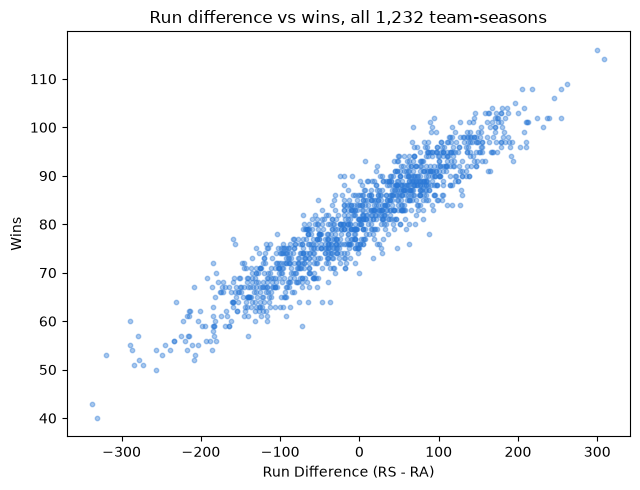

In [3]:
baseball['RD'] = baseball.RS - baseball.RA

fig, ax = plt.subplots(figsize = (6.5, 5))
ax.scatter(baseball.RD, baseball.W, s = 10, alpha = 0.4, color = '#2a78d6')
ax.set_xlabel('Run Difference (RS - RA)'); ax.set_ylabel('Wins')
ax.set_title('Run difference vs wins, all 1,232 team-seasons')
plt.tight_layout()
plt.savefig('outputs/rd_vs_wins.png', dpi = 120)
plt.show()

In [4]:
moneyball_era = baseball[baseball.Year < 2002]
print(f'pre-2002 (what the original notebook used): {len(moneyball_era)} team-seasons')
print(f'2002 and after (available here, never used by the original): {len(baseball) - len(moneyball_era)} team-seasons')

pre-2002 (what the original notebook used): 902 team-seasons
2002 and after (available here, never used by the original): 330 team-seasons


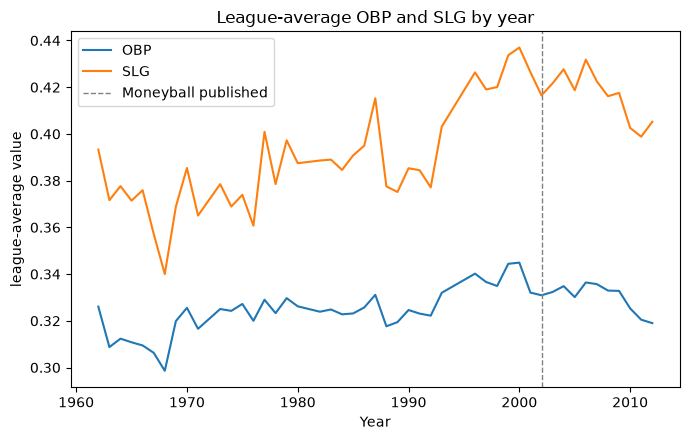

In [5]:
fig, ax = plt.subplots(figsize = (7, 4.5))
baseball.groupby('Year')[['OBP', 'SLG']].mean().plot(ax = ax)
ax.axvline(2002, color = 'gray', linestyle = '--', linewidth = 1, label = 'Moneyball published')
ax.legend()
ax.set_ylabel('league-average value')
ax.set_title('League-average OBP and SLG by year')
plt.tight_layout()
plt.savefig('outputs/obp_slg_trend.png', dpi = 120)
plt.show()

In [6]:
import os, json
os.makedirs('outputs', exist_ok = True)
summary = {
    'n_team_seasons': int(baseball.shape[0]),
    'year_range': [int(baseball.Year.min()), int(baseball.Year.max())],
    'n_pre_2002': int(len(moneyball_era)),
    'n_post_2002': int(len(baseball) - len(moneyball_era)),
}
with open('outputs/data_summary.json', 'w') as f:
    json.dump(summary, f, indent = 2)
summary

{'n_team_seasons': 1232,
 'year_range': [1962, 2012],
 'n_pre_2002': 902,
 'n_post_2002': 330}